In [1]:
# data manipulation
import numpy as np
import pandas as pd

# train/test split
from sktime.forecasting.model_selection import temporal_train_test_split

# detrender
from sktime.transformations.series.detrend import Detrender
from sktime.forecasting.trend import PolynomialTrendForecaster

# statistical interference
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.stattools import grangercausalitytests
from statsmodels.stats.stattools import durbin_watson
from statsmodels.stats.diagnostic import acorr_ljungbox, acorr_breusch_godfrey
from scipy.stats import jarque_bera
from statsmodels.stats.diagnostic import het_arch

# VAR model
from sktime.forecasting.var import VAR

# pipelining 
from sktime.forecasting.compose import TransformedTargetForecaster

# preprocessing
from sktime.transformations.series.adapt import TabularToSeriesAdaptor
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler

# 1) Data overwiew
First glance at the dataset.

In [2]:
multivariate_ts= pd.read_csv('/home/petewojtczak/datasets_csv/Weather Data.csv')
multivariate_ts.head(3)

,Date/Time,Temp_C,Dew Point Temp_C,Rel Hum_%,Wind Speed_km/h,Visibility_km,Press_kPa,Weather
0,1/1/2012 0:00,-1.8,-3.9,86,4,8.0,101.24,Fog
1,1/1/2012 1:00,-1.8,-3.7,87,4,8.0,101.24,Fog
2,1/1/2012 2:00,-1.8,-3.4,89,7,4.0,101.26,"Freezing Drizzle,Fog"


In [3]:
multivariate_ts['Date/Time'] = pd.to_datetime(multivariate_ts['Date/Time'])
multivariate_ts.set_index('Date/Time', inplace=True)
multivariate_ts.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 8784 entries, 2012-01-01 00:00:00 to 2012-12-31 23:00:00
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Temp_C            8784 non-null   float64
 1   Dew Point Temp_C  8784 non-null   float64
 2   Rel Hum_%         8784 non-null   int64  
 3   Wind Speed_km/h   8784 non-null   int64  
 4   Visibility_km     8784 non-null   float64
 5   Press_kPa         8784 non-null   float64
 6   Weather           8784 non-null   object 
dtypes: float64(4), int64(2), object(1)
memory usage: 549.0+ KB


_Weather_ will certainly need attention.

In [4]:
multivariate_ts.Weather.unique()

array(['Fog', 'Freezing Drizzle,Fog', 'Mostly Cloudy', 'Cloudy', 'Rain',
       'Rain Showers', 'Mainly Clear', 'Snow Showers', 'Snow', 'Clear',
       'Freezing Rain,Fog', 'Freezing Rain', 'Freezing Drizzle',
       'Rain,Snow', 'Moderate Snow', 'Freezing Drizzle,Snow',
       'Freezing Rain,Snow Grains', 'Snow,Blowing Snow', 'Freezing Fog',
       'Haze', 'Rain,Fog', 'Drizzle,Fog', 'Drizzle',
       'Freezing Drizzle,Haze', 'Freezing Rain,Haze', 'Snow,Haze',
       'Snow,Fog', 'Snow,Ice Pellets', 'Rain,Haze', 'Thunderstorms,Rain',
       'Thunderstorms,Rain Showers', 'Thunderstorms,Heavy Rain Showers',
       'Thunderstorms,Rain Showers,Fog', 'Thunderstorms',
       'Thunderstorms,Rain,Fog',
       'Thunderstorms,Moderate Rain Showers,Fog', 'Rain Showers,Fog',
       'Rain Showers,Snow Showers', 'Snow Pellets', 'Rain,Snow,Fog',
       'Moderate Rain,Fog', 'Freezing Rain,Ice Pellets,Fog',
       'Drizzle,Ice Pellets,Fog', 'Drizzle,Snow', 'Rain,Ice Pellets',
       'Drizzle,Snow,Fog', 

In [5]:
len(multivariate_ts.Weather.unique())

50

In [6]:
multivariate_ts.Weather.value_counts().head(20)

Mainly Clear                  2106
Mostly Cloudy                 2069
Cloudy                        1728
Clear                         1326
Snow                           390
Rain                           306
Rain Showers                   188
Fog                            150
Rain,Fog                       116
Drizzle,Fog                     80
Snow Showers                    60
Drizzle                         41
Snow,Fog                        37
Snow,Blowing Snow               19
Rain,Snow                       18
Haze                            16
Thunderstorms,Rain Showers      16
Drizzle,Snow,Fog                15
Freezing Rain                   14
Freezing Drizzle,Snow           11
Name: Weather, dtype: int64

_Visibility_km_ also needs attention.

In [7]:
multivariate_ts.Visibility_km.unique()

array([ 8. ,  4. ,  4.8,  6.4,  1.2, 12.9, 16.1, 25. , 19.3, 24.1,  9.7,
       11.3, 48.3,  3.2,  2.8,  2.4,  2. ,  0.8,  0.6,  1. ,  1.6,  3.6,
        0.2,  0.4])

In [8]:
len(multivariate_ts.Visibility_km.unique())

24

In [9]:
multivariate_ts.Visibility_km.value_counts().sort_index(ascending=False).head(15)

48.3    2014
25.0    3324
24.1    1921
19.3     281
16.1     224
12.9     174
11.3      36
9.7      181
8.0      122
6.4      129
4.8       79
4.0       55
3.6       11
3.2       42
2.8       15
Name: Visibility_km, dtype: int64

## 1.1) Plots
Time series visualizations and observations.

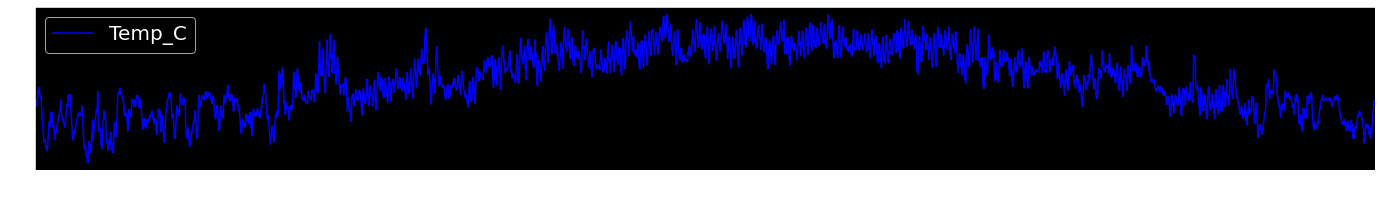

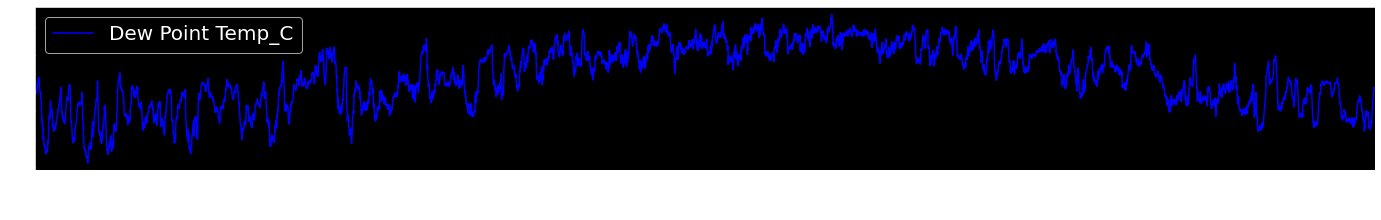

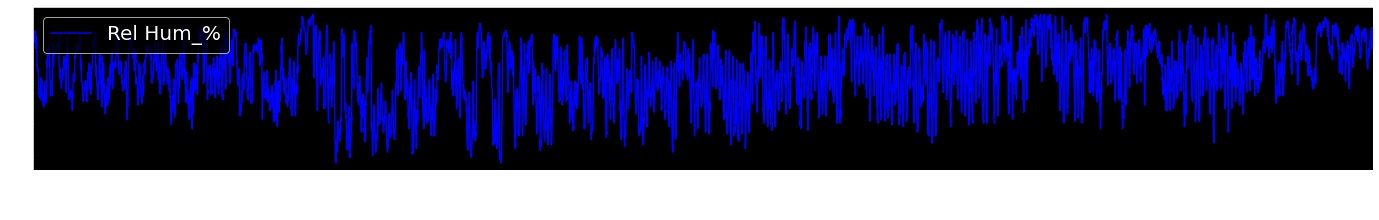

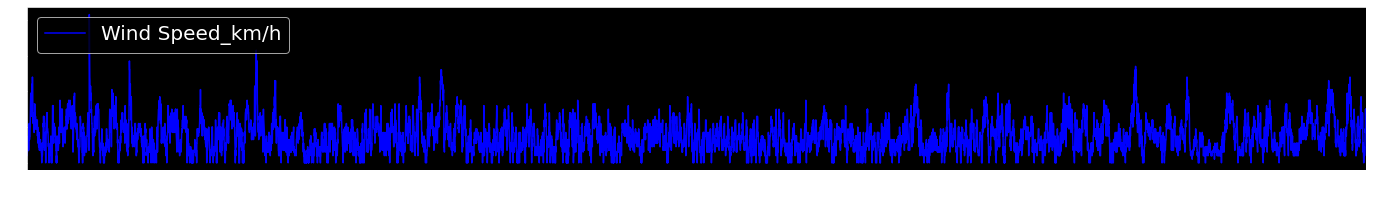

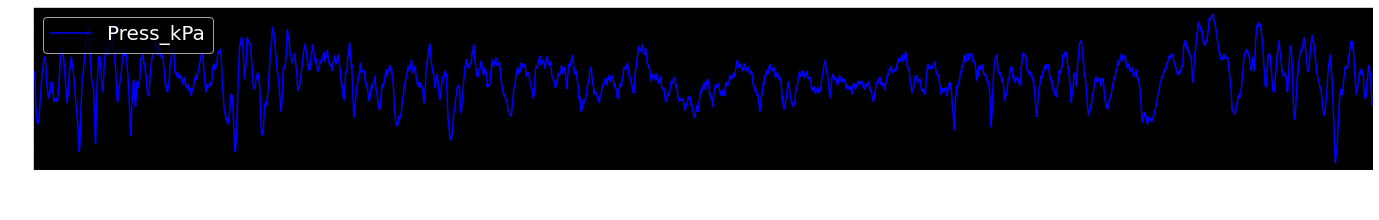

In [10]:
# continous variables plots
import matplotlib.pyplot as plt
plt.style.use('dark_background')
%matplotlib inline

for col in multivariate_ts.drop(columns=['Visibility_km','Weather']).columns:
    multivariate_ts[col].plot(color='blue')
    plt.gcf().set_size_inches(24, 3)
    plt.legend(loc=2, prop={'size': 20})
    plt.show()

Two variables, _Temp_C_ and _Dew Point Temp_C_, demonstrate trend-like patterns that warrant some consideration.

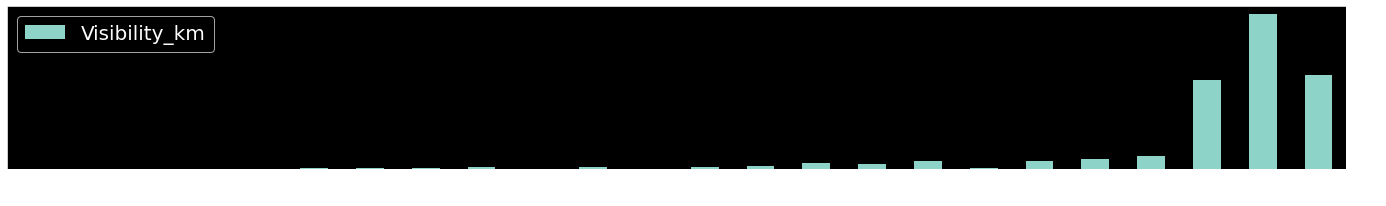

In [11]:
# Visibility_km plot
ax = multivariate_ts.Visibility_km.value_counts(sort=False).sort_index(ascending=True).plot(kind='bar')
plt.gcf().set_size_inches(24, 3)
plt.legend(loc=2, prop={'size': 20})
ax.yaxis.tick_right()
plt.show()

_Visibility_km_, after some re-engineering, will be treated as ordinal variable.

# 2) Data wrangling
Here, we do some statistical interference considering continous data as well as feature engineering of remaining variables.

## 2.1) Train/test split
Since statistical interference is about to occur, train/test split is conducted.

In [12]:
# we will forecast last 72 hours
y_train, y_test = temporal_train_test_split(multivariate_ts, test_size=72)

## 2.2) Stationarity
Stationarity is a key concept in time series analysis, indicating that the statistical properties of a series, such as its mean, variance, and autocorrelation structure, do not change over time. The Augmented Dickey-Fuller (ADF) test is a widely used statistical test for assessing the stationarity of a time series data. 

First, as mentioned in section 1.1, two variables _Temp_C_ and _Dew Point Temp_C_ needs to be detrended. The plots indicate that second degree polinominal looks like a good fit.

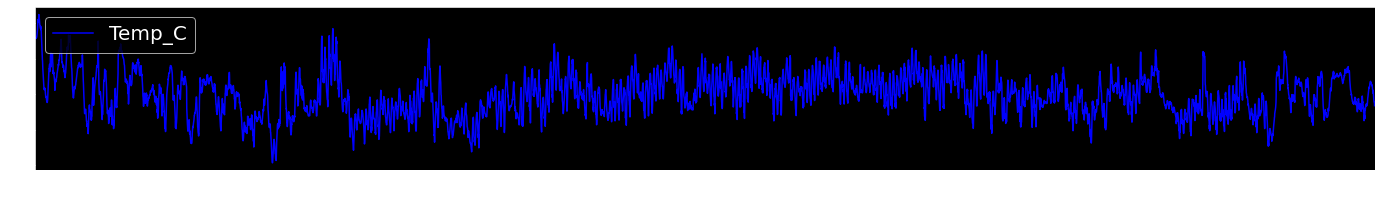

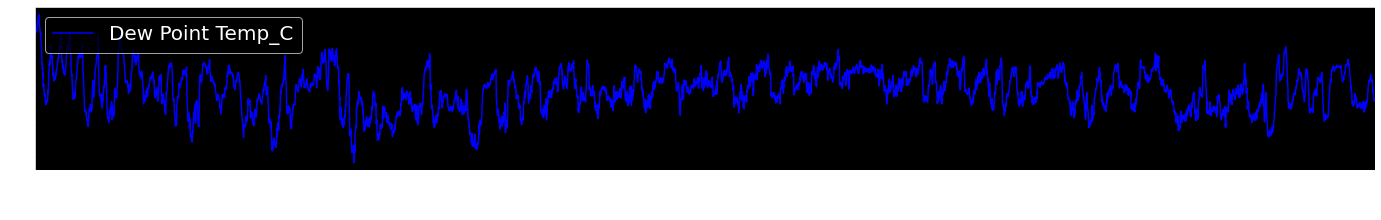

In [13]:
detrender = Detrender(forecaster=PolynomialTrendForecaster(degree=2))
detrended_var = detrender.fit_transform(y_train[['Temp_C','Dew Point Temp_C']])
for col in detrended_var.columns:
    detrended_var[col].plot(color='blue')
    plt.gcf().set_size_inches(24, 3)
    plt.legend(loc=2, prop={'size': 20})
    plt.show()

Let's progress to stationarity testing. Given the plots, we expect all time-series to be stationary.

In [14]:
# adopted from https://www.machinelearningplus.com/time-series/vector-autoregression-examples-python/
def adfuller_test(series, signif=0.05, name='', verbose=False):
    """Perform ADFuller to test for Stationarity of given series and print report"""
    r = adfuller(series, autolag='AIC')
    output = {'test_statistic':round(r[0], 4), 'pvalue':round(r[1], 4), 'n_lags':round(r[2], 4), 'n_obs':r[3]}
    p_value = output['pvalue'] 
    def adjust(val, length= 6): return str(val).ljust(length)

    print(f'    Augmented Dickey-Fuller Test on "{name}"', "\n   ", '-'*47)
    print(f' Null Hypothesis: Data has unit root. Non-Stationary.')
    print(f' Significance Level    = {signif}')
    print(f' Test Statistic        = {output["test_statistic"]}')
    print(f' No. Lags Chosen       = {output["n_lags"]}')

    for key,val in r[4].items():
        print(f' Critical value {adjust(key)} = {round(val, 3)}')

    if p_value <= signif:
        print(f" => P-Value = {p_value}. Rejecting Null Hypothesis.")
        print(f" => Series is Stationary.")
    else:
        print(f" => P-Value = {p_value}. Weak evidence to reject the Null Hypothesis.")
        print(f" => Series is Non-Stationary.")

In [15]:
for name, column in detrended_var.iteritems():
    adfuller_test(column, name=column.name)
    print('\n')

    Augmented Dickey-Fuller Test on "Temp_C" 
    -----------------------------------------------
 Null Hypothesis: Data has unit root. Non-Stationary.
 Significance Level    = 0.05
 Test Statistic        = -8.6481
 No. Lags Chosen       = 37
 Critical value 1%     = -3.431
 Critical value 5%     = -2.862
 Critical value 10%    = -2.567
 => P-Value = 0.0. Rejecting Null Hypothesis.
 => Series is Stationary.


    Augmented Dickey-Fuller Test on "Dew Point Temp_C" 
    -----------------------------------------------
 Null Hypothesis: Data has unit root. Non-Stationary.
 Significance Level    = 0.05
 Test Statistic        = -9.8298
 No. Lags Chosen       = 32
 Critical value 1%     = -3.431
 Critical value 5%     = -2.862
 Critical value 10%    = -2.567
 => P-Value = 0.0. Rejecting Null Hypothesis.
 => Series is Stationary.




In [16]:
# remaining continous variables are stationary as well
for name, column in multivariate_ts.drop(columns=['Visibility_km','Weather','Temp_C', 'Dew Point Temp_C']).iteritems():
    adfuller_test(column, name=column.name)
    print('\n')

    Augmented Dickey-Fuller Test on "Rel Hum_%" 
    -----------------------------------------------
 Null Hypothesis: Data has unit root. Non-Stationary.
 Significance Level    = 0.05
 Test Statistic        = -11.5509
 No. Lags Chosen       = 26
 Critical value 1%     = -3.431
 Critical value 5%     = -2.862
 Critical value 10%    = -2.567
 => P-Value = 0.0. Rejecting Null Hypothesis.
 => Series is Stationary.


    Augmented Dickey-Fuller Test on "Wind Speed_km/h" 
    -----------------------------------------------
 Null Hypothesis: Data has unit root. Non-Stationary.
 Significance Level    = 0.05
 Test Statistic        = -14.2484
 No. Lags Chosen       = 28
 Critical value 1%     = -3.431
 Critical value 5%     = -2.862
 Critical value 10%    = -2.567
 => P-Value = 0.0. Rejecting Null Hypothesis.
 => Series is Stationary.


    Augmented Dickey-Fuller Test on "Press_kPa" 
    -----------------------------------------------
 Null Hypothesis: Data has unit root. Non-Stationary.
 Sign

## 2.3) Granger’s causality tests
Granger causality tests are primarily designed for continuous time series data. They assess whether past values of one continuous variable can predict another continuous variable beyond what could be predicted by its own past values. It is important to note that Granger causality does not imply true causality in the philosophical or scientific sense, but rather a predictive relationship based on historical data.

In [17]:
maxlag=12
test = 'ssr_chi2test'
def grangers_causation_matrix(data, variables, test='ssr_chi2test', verbose=False):    
    """Check Granger Causality of all possible combinations of the Time series.
    The rows are the response variable, columns are predictors. The values in the table 
    are the P-Values. P-Values lesser than the significance level (0.05), implies 
    the Null Hypothesis that the coefficients of the corresponding past values is 
    zero, that is, the X does not cause Y can be rejected.

    data      : pandas dataframe containing the time series variables
    variables : list containing names of the time series variables.
    """
    df = pd.DataFrame(np.zeros((len(variables), len(variables))), columns=variables, index=variables)
    for c in df.columns:
        for r in df.index:
            test_result = grangercausalitytests(data[[r, c]], maxlag=maxlag, verbose=False)
            p_values = [round(test_result[i+1][0][test][1],4) for i in range(maxlag)]
            if verbose: print(f'Y = {r}, X = {c}, P Values = {p_values}')
            min_p_value = np.min(p_values)
            df.loc[r, c] = min_p_value
    df.columns = [var + '_x' for var in variables]
    df.index = [var + '_y' for var in variables]
    return df
# adopted from https://www.machinelearningplus.com/time-series/vector-autoregression-examples-python/

In [18]:
y_train_stationary = detrended_var.join(y_train[['Rel Hum_%','Wind Speed_km/h','Press_kPa']])
grangers_causation_matrix(y_train_stationary, variables = y_train_stationary.columns)

/home/petewojtczak/anaconda3/lib/python3.8/site-packages/statsmodels/base/model.py:1871: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 3, but rank is 1
  warnings.warn('covariance of constraints does not have full '
/home/petewojtczak/anaconda3/lib/python3.8/site-packages/statsmodels/base/model.py:1871: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 4, but rank is 1
  warnings.warn('covariance of constraints does not have full '


,Temp_C_x,Dew Point Temp_C_x,Rel Hum_%_x,Wind Speed_km/h_x,Press_kPa_x
Temp_C_y,1.0,0.0,0.0000,0.0000,0.0
Dew Point Temp_C_y,0.0,1.0,0.0001,0.0000,0.0
Rel Hum_%_y,0.0,0.0,1.0000,0.0000,0.0
Wind Speed_km/h_y,0.0,0.0,0.0000,1.0000,0.0
Press_kPa_y,0.0,0.0,0.0000,0.0043,1.0


Since all values in the Granger causality matrix are smaller than 0.05 (except the diagonal elements), it is indicated that there is statistically significant evidence of Granger causality between continous variables in the model.

## 2.4) Feature engineering

### Visibility_km

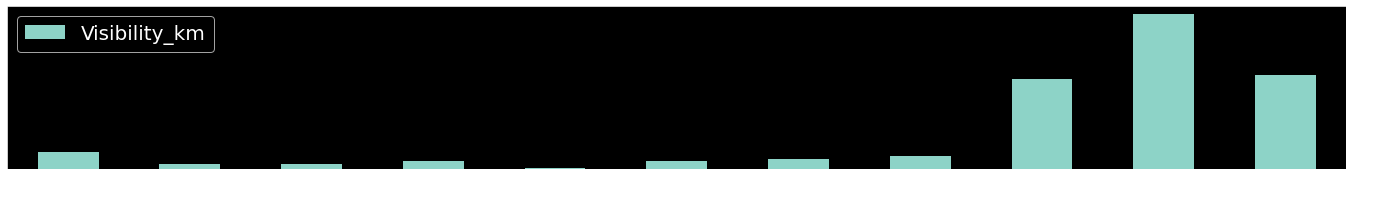

In [19]:
# ends of the scale has been cut; we intend to assume this variable to be ordinal (and apply minmax scaler)
y_train.loc[y_train['Visibility_km'] <= 5, 'Visibility_km'] = 5
y_train.loc[y_train['Visibility_km'] == 48.3, 'Visibility_km'] = 30
y_test.loc[y_test['Visibility_km'] <= 5, 'Visibility_km'] = 5
y_test.loc[y_test['Visibility_km'] == 48.3, 'Visibility_km'] = 30
# Visibility_km plot
ax = y_train.Visibility_km.value_counts(sort=False).sort_index(ascending=True).plot(kind='bar')
plt.gcf().set_size_inches(24, 3)
plt.legend(loc=2, prop={'size': 20})
ax.yaxis.tick_right()
plt.show()

### Weather

In [20]:
no_precipitation = [
    'Fog', 'Mostly Cloudy', 'Cloudy', 'Mainly Clear', 'Clear', 
    'Freezing Fog', 'Haze'
]

major_precipitation = [
    'Thunderstorms,Heavy Rain Showers', 'Thunderstorms,Rain Showers,Fog',
    'Thunderstorms,Moderate Rain Showers,Fog', 'Moderate Snow,Blowing Snow', 
    'Thunderstorms,Rain', 'Thunderstorms,Rain,Fog',  'Thunderstorms,Rain Showers',
    'Rain', 'Snow', 'Moderate Snow',   
    'Rain Showers,Snow Showers', 'Rain,Snow', 'Rain Showers', 
    'Rain,Ice Pellets', 'Snow Showers,Fog', 'Moderate Rain,Fog',
]

minor_precipitation = [
    'Freezing Drizzle,Fog', 'Freezing Rain,Fog', 'Freezing Rain',
    'Freezing Drizzle', 'Snow Showers', 'Freezing Drizzle,Snow', 
    'Freezing Rain,Snow Grains', 'Snow,Blowing Snow', 'Rain,Fog', 
    'Drizzle,Fog', 'Drizzle', 'Freezing Drizzle,Haze', 
    'Freezing Rain,Haze', 'Snow,Haze', 'Snow,Fog', 'Snow,Ice Pellets', 
    'Rain,Haze', 'Thunderstorms,Rain', 'Rain Showers,Fog', 'Snow Pellets', 
    'Rain,Snow,Fog', 'Freezing Rain,Ice Pellets,Fog', 
    'Drizzle,Ice Pellets,Fog', 'Drizzle,Snow', 'Drizzle,Snow,Fog', 
    'Rain,Snow Grains', 'Rain,Snow,Ice Pellets'
]
# lists generated by ChatGPT

In [21]:
# only single description was not assigned to any of the list
combined_list = no_precipitation + major_precipitation + minor_precipitation

missing_elements = [item for item in y_train.Weather.unique() if item not in combined_list]

if missing_elements:
    print(f"Elements of Weather.unique() not found in the combined list: {missing_elements}")
else:
    print("All elements of the other list are present in the combined list.")

Elements of Weather.unique() not found in the combined list: ['Thunderstorms']


In [22]:
major_precipitation.append('Thunderstorms')

In [23]:
# one duplicate found in lists
seen = set()
duplicates = set()

for item in combined_list:
    if item in seen:
        duplicates.add(item)
    else:
        seen.add(item)

if duplicates:
    print(f"Duplicates found: {duplicates}")
else:
    print("No duplicates found.")

Duplicates found: {'Thunderstorms,Rain'}


In [24]:
minor_precipitation.remove('Thunderstorms,Rain')

#### Ordinal feature _precip_num_ is created

In [25]:
y_train['precip_num'] = 0
y_test['precip_num'] = 0
for weather in multivariate_ts.Weather.unique():
    if weather in major_precipitation:
        y_train.loc[y_train['Weather'] == weather, 'precip_num'] = 1
        y_test.loc[y_test['Weather'] == weather, 'precip_num'] = 1
    elif weather in minor_precipitation:
        y_train.loc[y_train['Weather'] == weather, 'precip_num'] = 0.5
        y_test.loc[y_test['Weather'] == weather, 'precip_num'] = 0.5
    else:
        y_train.loc[y_train['Weather'] == weather, 'precip_num'] = 0
        y_test.loc[y_test['Weather'] == weather, 'precip_num'] = 0

In [26]:
y_train['precip_num'] .value_counts()

0.0    7364
1.0     926
0.5     422
Name: precip_num, dtype: int64

#### Binary feature _fog_ is created

In [27]:
y_train['fog'] = 0
y_train.loc[y_train['Weather'].str.contains('fog', case=False), 'fog'] = 1
y_train.loc[y_train['Weather'].str.contains('haze', case=False), 'fog'] = 1
y_test['fog'] = 0
y_test.loc[y_test['Weather'].str.contains('fog', case=False), 'fog'] = 1
y_test.loc[y_test['Weather'].str.contains('haze', case=False), 'fog'] = 1

In [28]:
y_train['fog'] .value_counts()

0    8284
1     428
Name: fog, dtype: int64

#### Binary feature _drizzle_ is created

In [29]:
y_train['drizzle'] = 0
y_train.loc[y_train['Weather'].str.contains('drizzle', case=False), 'drizzle'] = 1
y_test['drizzle'] = 0
y_test.loc[y_test['Weather'].str.contains('drizzle', case=False), 'drizzle'] = 1

In [30]:
y_train['drizzle'].value_counts()

0    8546
1     166
Name: drizzle, dtype: int64

In [31]:
y_train.drop('Weather', axis=1, inplace=True)
y_test.drop('Weather', axis=1, inplace=True)

In [32]:
y_train.tail(3)

,Temp_C,Dew Point Temp_C,Rel Hum_%,Wind Speed_km/h,Visibility_km,Press_kPa,precip_num,fog,drizzle
Date/Time,,,,,,,,,
2012-12-28 21:00:00,-9.8,-12.5,81,19,25.0,101.36,0.0,0,0
2012-12-28 22:00:00,-9.9,-12.5,81,17,25.0,101.38,0.0,0,0
2012-12-28 23:00:00,-10.9,-13.2,83,13,25.0,101.38,0.0,0,0


In [33]:
y_test.head(3)

,Temp_C,Dew Point Temp_C,Rel Hum_%,Wind Speed_km/h,Visibility_km,Press_kPa,precip_num,fog,drizzle
Date/Time,,,,,,,,,
2012-12-29 00:00:00,-11.6,-13.5,86,13,25.0,101.35,0.0,0,0
2012-12-29 01:00:00,-11.9,-13.6,87,11,25.0,101.31,0.0,0,0
2012-12-29 02:00:00,-11.8,-13.1,90,13,25.0,101.33,0.0,0,0


# 3) Modeling
Here, we construct a pipeline for handling the preprocessing of the variables and VAR model estimation. Also, statistical testing is performed in order to validate the model. 

## 3.1) VAR estimation 
In terms of preprocessing, the continuous variables _Temp_C_ and _Dew Point Temp_C_ are detrended using a second-degree polynomial. Next, all continuous variables are scaled using the StandardScaler. The ordinal variable _Visibility_km_ is scaled using the MinMaxScaler; remaining variables are scaled appropriately for estimation.

In [34]:
fcst_pipeline = TransformedTargetForecaster(
    steps=[
        ('detrender', Detrender(forecaster=PolynomialTrendForecaster(degree=2)), ['Temp_C', 'Dew Point Temp_C']),
        ('z-score', TabularToSeriesAdaptor(StandardScaler()), ['Temp_C', 'Dew Point Temp_C', 'Rel Hum_%', 'Wind Speed_km/h', 'Press_kPa']),
        ('MinMax_scaler', TabularToSeriesAdaptor(MinMaxScaler()), ['Visibility_km']),
        ("forecaster", VAR(maxlags=50, ic='aic'))
    ]
)

In [35]:
fcst_pipeline.fit(y_train)

TransformedTargetForecaster(steps=[('detrender',
                                    Detrender(forecaster=PolynomialTrendForecaster(degree=2)),
                                    ['Temp_C', 'Dew Point Temp_C']),
                                   ('z-score',
                                    TabularToSeriesAdaptor(transformer=StandardScaler()),
                                    ['Temp_C', 'Dew Point Temp_C', 'Rel Hum_%',
                                     'Wind Speed_km/h', 'Press_kPa']),
                                   ('MinMax_scaler',
                                    TabularToSeriesAdaptor(transformer=MinMaxScaler()),
                                    ['Visibility_km']),
                                   ('forecaster', VAR(ic='aic', maxlags=50))])

## 3.2) Model diagnostics
Here, we perform statistical interference in order to validate the model. Residual serial correlation, normality and heteroscedasticity of the residuals are tested.

In [36]:
# significance level
alpha = 0.05

### Residual Serial Correlation Tests

In [37]:
residuals = fcst_pipeline.predict_residuals(y=y_train)
residuals.shape

(8712, 9)

In [38]:
residuals.dropna(inplace=True)
residuals.shape

(8685, 9)

In [39]:
# durbin-Watson Test
dw_results = {col: durbin_watson(residuals[col]) for col in residuals.drop(columns=['drizzle','fog','precip_num','Visibility_km']).columns}
print("Durbin-Watson Test Results:")
for col, dw_stat in dw_results.items():
    if dw_stat < 1.5 or dw_stat > 2.5:
        print(f"   Serial correlation is present in {col} || dw_stat: {round(dw_stat, 3)}")
    else:
        print(f"   No serial correlation in {col} || dw_stat: {round(dw_stat, 3)}")
        
# Ljung-Box Test
print("\nLjung-Box Test Results:")
ljung_box_results = {}
for col in residuals.drop(columns=['drizzle','fog','precip_num','Visibility_km']).columns:
    ljung_box_results[col] = acorr_ljungbox(residuals[col], lags=[10], return_df=True)
    p_values = ljung_box_results[col]['lb_pvalue']
    if any(p < alpha for p in p_values):
        print(f"   Serial correlation is present in {col}")
    else:
        print(f"   No serial correlation in {col}")

Durbin-Watson Test Results:
   No serial correlation in Temp_C || dw_stat: 2.001
   No serial correlation in Dew Point Temp_C || dw_stat: 2.0
   No serial correlation in Rel Hum_% || dw_stat: 1.999
   No serial correlation in Wind Speed_km/h || dw_stat: 2.0
   No serial correlation in Press_kPa || dw_stat: 2.013

Ljung-Box Test Results:
   No serial correlation in Temp_C
   No serial correlation in Dew Point Temp_C
   No serial correlation in Rel Hum_%
   No serial correlation in Wind Speed_km/h
   No serial correlation in Press_kPa


###  Jarque-Bera test for residual normality

In [40]:
print("Jarque-Bera Test Results:")
for col in residuals.drop(columns=['drizzle','fog','precip_num','Visibility_km']).columns:
    jb_stat, jb_p_value = jarque_bera(residuals[col])
    if jb_p_value < alpha:
        print(f"    Residuals are not normally distributed for {col} || test Statistic: {jb_stat} || p-value: {jb_p_value}")
    else:
        print(f"    Residuals are normally distributed for {col} ||test Statistic: {jb_stat} || p-value: {jb_p_value}")

Jarque-Bera Test Results:
    Residuals are not normally distributed for Temp_C || test Statistic: 21879.511470320565 || p-value: 0.0
    Residuals are not normally distributed for Dew Point Temp_C || test Statistic: 9671.717942530353 || p-value: 0.0
    Residuals are not normally distributed for Rel Hum_% || test Statistic: 10108.7288146999 || p-value: 0.0
    Residuals are not normally distributed for Wind Speed_km/h || test Statistic: 14731.373567927765 || p-value: 0.0
    Residuals are not normally distributed for Press_kPa || test Statistic: 11587.856381569149 || p-value: 0.0


### Heteroscedasticity of residuals (Engle's ARCH Test)

In [41]:
print("Engle's ARCH Test for Heteroscedasticity:")
for col in residuals.drop(columns=['drizzle','fog','precip_num','Visibility_km']).columns:
    test_stat, p_value, _, _ = het_arch(residuals[col])
    if p_value < alpha:
        print(f"    Residuals are heteroscedastic for {col} || test Statistic: {test_stat} || p-value: {p_value}")
    else:
        print(f"    Residuals are homoscedastic for {col} || test Statistic: {test_stat} || p-value: {p_value}")

Engle's ARCH Test for Heteroscedasticity:
    Residuals are heteroscedastic for Temp_C || test Statistic: 196.27160612207044 || p-value: 9.663663315576227e-37
    Residuals are heteroscedastic for Dew Point Temp_C || test Statistic: 326.05264645563557 || p-value: 4.7654948992244216e-64
    Residuals are heteroscedastic for Rel Hum_% || test Statistic: 158.0185206784222 || p-value: 8.307641254851129e-29
    Residuals are heteroscedastic for Wind Speed_km/h || test Statistic: 51.67743864953933 || p-value: 1.3092147795750073e-07
    Residuals are heteroscedastic for Press_kPa || test Statistic: 813.7106264295319 || p-value: 2.327081047806644e-168


### Diagnostics considerations

The model diagnostics reveal that residuals are heteroscedastic and not normally distributed. Possible actions to mitigate these problems may include:
* Re-evaluating the Model Specification (lag order, additional endogenous or exogenous variables)
* Further transformation of Variables (log Transformation, Box-Cox transformation, differencing)
* Model extensions like GARCH (Generalized Autoregressive Conditional Heteroscedasticity) to explicitly model the changing variance over time.
* Non-linear Models (if non-linear relationships are suspected in data that a linear VAR model cannot capture)

While using a VAR model with heteroscedastic and not normally distributed residuals can complicate the analysis and inference of a VAR model, it does not render the model unusable. It's important to understand the implications and to be aware of the potential limitations:
* Impact on Inference: The validity of standard statistical tests (e.g., t-tests and F-tests) and confidence intervals derived from the model will be affected
* Impact on Forecast Accuracy: While non-normal residuals might not drastically impact point forecasts, prediction intervals will be less reliable.

Being mindful of the potential biases and inaccuracies in the point forecasts due to the violated assumptions, we will proceed to evaluate the accuracy of point forecasts using out-of-sample data and appropriate metrics in this mock dataset example case. In professional applications, other multivariate forecasters would likely be the preferred solution.

# 4) Forecasting and model evaluation

In [42]:
fcst = fcst_pipeline.predict(fh=y_test.index)
fcst.head(3)

,Temp_C,Dew Point Temp_C,Rel Hum_%,Wind Speed_km/h,Visibility_km,Press_kPa,precip_num,fog,drizzle
Date/Time,,,,,,,,,
2012-12-29 00:00:00,-10.851174,-13.147229,82.538079,14.078580,22.590433,101.388578,0.155404,0.059623,-0.040274
2012-12-29 01:00:00,-10.896633,-13.293298,81.886630,14.469662,21.470929,101.396224,0.286603,0.068116,0.011077
2012-12-29 02:00:00,-10.870761,-13.240728,81.785788,13.029184,21.395965,101.394048,0.212727,0.063471,0.033164


In [43]:
fcst.shape

(72, 9)

In [44]:
y_test.head(3)

,Temp_C,Dew Point Temp_C,Rel Hum_%,Wind Speed_km/h,Visibility_km,Press_kPa,precip_num,fog,drizzle
Date/Time,,,,,,,,,
2012-12-29 00:00:00,-11.6,-13.5,86,13,25.0,101.35,0.0,0,0
2012-12-29 01:00:00,-11.9,-13.6,87,11,25.0,101.31,0.0,0,0
2012-12-29 02:00:00,-11.8,-13.1,90,13,25.0,101.33,0.0,0,0


In [45]:
y_test.shape

(72, 9)